# 14 — SHAP Explainability of the Final Model

This notebook applies SHAP (SHapley Additive exPlanations) to the final model selected during the evaluation stage.

The selected model is the Full Multimodal Random Forest, which achieved the strongest overall validation and test performance among all candidate models.

The objectives of this notebook are to:

- Generate global SHAP explanations.
- Identify the most influential predictors.
- Compare feature importance across modalities.
- Analyze contributions by neurological task.
- Analyze contributions by sensor type.
- Analyze contributions by wrist.
- Examine questionnaire importance.
- Produce participant-level explanations for individual predictions.

The notebook uses the saved fitted Week 5 pipeline and does not retrain or modify the model.

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd

import shap
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",100)
pd.set_option("display.max_rows",100)

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT/"src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT/"data"/"processed"
MODELS_DIR = PROJECT_ROOT/"models"

OUTPUTS_DIR = PROJECT_ROOT/"outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)
SHAP_DIR = OUTPUTS_DIR / "shap"

SHAP_FIGURES = SHAP_DIR / "figures"
SHAP_TABLES = SHAP_DIR / "tables"

SHAP_FIGURES.mkdir(parents=True, exist_ok=True)
SHAP_TABLES.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = OUTPUTS_DIR/"figures"
TABLES_DIR = OUTPUTS_DIR/"tables"

FIGURES_DIR.mkdir(exist_ok=True,parents=True)
TABLES_DIR.mkdir(exist_ok=True,parents=True)

## Load Final Model

The explainability analysis is performed using the final model selected after validation and test evaluation.

Model:
- Full Multimodal
- Random Forest

In [3]:
MODEL_PATH = MODELS_DIR/"full_multimodal_xgboost.joblib"

pipeline = joblib.load(MODEL_PATH)

pipeline.named_steps

{'preprocessing': ColumnTransformer(transformers=[('numerical',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['CrossArms_Left_AccX_Mean',
                                   'CrossArms_Right_AccX_Mean',
                                   'DrinkGlas_Left_AccX_Mean',
                                   'DrinkGlas_Right_AccX_Mean',
                                   'Entrainment_Left_AccX_Mean',
                                   'Entrainment_Right_AccX_Mean',
                                   'HoldWeight_Left_AccX_Mean',
                                   'HoldWeight_Righ...
                                   'Entrainment_Right_AccX_Median',
                                   'HoldWeight_Left_AccX_Median',
                                   'HoldWeight_Right_AccX_Median', .

## Load Held-Out Test Dataset

SHAP explanations are generated using the unseen held-out test set in order to explain the predictions of the final deployed model.

In [4]:
TEST_PATH = DATA_DIR/"test_multimodal_full_task_aware.csv"
test_df = pd.read_csv(TEST_PATH)
y_test = test_df["label"]
X_raw = test_df[pipeline.feature_names_in_]

## Recover the Final Feature Set
The Random Forest model was trained after preprocessing, variance filtering, and feature selection.
Therefore, SHAP explanations are generated using the final selected predictors rather than the complete set of raw variables.

In [5]:
preprocessor = pipeline.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()
variance = pipeline.named_steps["variance_filter"]
feature_after_variance = feature_names[
    variance.get_support()
]
selector = pipeline.named_steps["feature_selection"]
selected_features = feature_after_variance[
    selector.get_support()
]
selected_features = pd.Series(selected_features,name="Selected Feature")
print(f"Selected features: {len(selected_features)}")
display(selected_features.to_frame())

Selected features: 500


,Selected Feature
0,numerical__CrossArms_Right_AccX_Mean
1,numerical__TouchIndex_Right_AccX_Mean
2,numerical__PointFinger_Left_AccX_Median
3,numerical__TouchIndex_Right_AccX_Median
4,numerical__HoldWeight_Left_AccX_Std
...,...
495,numerical__weight_kg
496,categorical__gender_Female
497,categorical__gender_Male
498,categorical__family_history_first_degree_No


## Transform the Test Data
The fitted preprocessing pipeline is applied exactly as learned during model training.
No preprocessing step is refitted.

In [6]:
X_processed = pipeline.named_steps["preprocessing"].transform(X_raw)
X_processed = pipeline.named_steps["variance_filter"].transform(X_processed)
X_processed = pipeline.named_steps["feature_selection"].transform(X_processed)
X_processed = pd.DataFrame(
    X_processed,
    columns=selected_features
)
X_processed.head()

Selected Feature,numerical__CrossArms_Right_AccX_Mean,numerical__TouchIndex_Right_AccX_Mean,numerical__PointFinger_Left_AccX_Median,numerical__TouchIndex_Right_AccX_Median,numerical__HoldWeight_Left_AccX_Std,numerical__LiftHold_Left_AccX_Std,numerical__StretchHold_Left_AccX_Std,numerical__CrossArms_Left_AccX_IQR,numerical__CrossArms_Right_AccX_IQR,numerical__DrinkGlas_Left_AccX_IQR,numerical__DrinkGlas_Right_AccX_IQR,numerical__HoldWeight_Left_AccX_IQR,numerical__LiftHold_Left_AccX_IQR,numerical__LiftHold_Right_AccX_IQR,numerical__PointFinger_Left_AccX_IQR,numerical__PointFinger_Right_AccX_IQR,numerical__StretchHold_Left_AccX_IQR,numerical__TouchNose_Left_AccX_IQR,numerical__TouchNose_Right_AccX_IQR,numerical__HoldWeight_Left_AccX_RMS,numerical__LiftHold_Left_AccX_RMS,numerical__StretchHold_Left_AccX_RMS,numerical__Entrainment_Left_AccY_Median,numerical__LiftHold_Left_AccY_Std,numerical__LiftHold_Right_AccY_Std,numerical__StretchHold_Left_AccY_Std,numerical__LiftHold_Right_AccY_Min,numerical__TouchIndex_Right_AccY_Min,numerical__LiftHold_Left_AccY_Max,numerical__CrossArms_Left_AccY_IQR,numerical__CrossArms_Right_AccY_IQR,numerical__DrinkGlas_Left_AccY_IQR,numerical__DrinkGlas_Right_AccY_IQR,numerical__HoldWeight_Left_AccY_IQR,numerical__HoldWeight_Right_AccY_IQR,numerical__LiftHold_Left_AccY_IQR,numerical__LiftHold_Right_AccY_IQR,numerical__StretchHold_Left_AccY_IQR,numerical__LiftHold_Left_AccY_RMS,numerical__LiftHold_Right_AccY_RMS,numerical__StretchHold_Left_AccY_RMS,numerical__StretchHold_Right_AccZ_Mean,numerical__PointFinger_Left_AccZ_Median,numerical__PointFinger_Right_AccZ_Median,numerical__TouchIndex_Left_AccZ_Median,numerical__TouchNose_Left_AccZ_Median,numerical__TouchNose_Right_AccZ_Median,numerical__DrinkGlas_Left_AccZ_Std,numerical__HoldWeight_Left_AccZ_Std,numerical__LiftHold_Left_AccZ_Std,...,numerical__TouchNose_RightWrist_gyro_magnitude_dominant_frequency,numerical__TouchNose_RightWrist_gyro_magnitude_spectral_centroid,numerical__TouchNose_RightWrist_gyro_magnitude_spectral_entropy,numerical__TouchNose_RightWrist_gyro_magnitude_spectral_power,numerical__TouchNose_RightWrist_gyro_x_spectral_entropy,numerical__TouchNose_RightWrist_gyro_y_dominant_frequency,numerical__TouchNose_RightWrist_gyro_y_spectral_centroid,numerical__TouchNose_RightWrist_gyro_y_spectral_power,numerical__TouchNose_RightWrist_gyro_z_spectral_entropy,numerical__PointFinger_Gyro_Magnitude_Energy_difference,numerical__Q01,numerical__Q02,numerical__Q03,numerical__Q05,numerical__Q07,numerical__Q08,numerical__Q09,numerical__Q10,numerical__Q12,numerical__Q13,numerical__Q14,numerical__Q15,numerical__Q16,numerical__Q18,numerical__Q19,numerical__Q20,numerical__Q21,numerical__Q22,numerical__Q24,numerical__Q25,numerical__Q26,numerical__Q27,numerical__Q28,numerical__Q29,numerical__Q30,numerical__gastrointestinal_count,numerical__urinary_count,numerical__pain_count,numerical__miscellaneous_count,numerical__apathy_attention_memory_count,numerical__distortion_perception_count,numerical__sexual_function_count,numerical__cardiovascular_count,numerical__sleep_fatigue_count,numerical__height_cm,numerical__weight_kg,categorical__gender_Female,categorical__gender_Male,categorical__family_history_first_degree_No,categorical__alcohol_effect_on_tremor_Improvement
0,0.594623,0.784478,-1.354586,-1.061677,0.034718,2.904390,0.285979,0.542220,0.259951,0.582039,0.398666,0.376527,4.048594,1.820827,1.753691,1.337923,0.486154,0.392573,0.726662,0.034517,2.903495,0.285247,-0.406929,1.843606,0.518307,0.158010,-0.913936,0.148662,2.232418,0.366340,0.055296,0.612033,0.218409,-0.108663,-0.071675,2.150487,0.940460,0.268935,1.843380,0.518006,0.157882,0.344650,0.772586,-0.102434,0.253931,0.159716,-0.088506,0.858052,-0.071021,2.564897,...,0.867809,0.736190,-0.473362,0.745831,-0.966208,0.979853,0.516662,-0.007396,-0.685584,0.657409,-0.657506,-0.705491,1.417453,1.334039,1.690806,0.884652,-1.210853,-0.424094,-0.724970,-0.596131,-0.334461,-0.836350,1.467599,-0.511408,-0.614940,-0.720082,-

## Compute SHAP Values
TreeExplainer is used because the final model is a Random Forest classifier.
SHAP values are computed for all participants in the held-out test set.

In [7]:
# Extract trained Random Forest classifier
classifier = pipeline.named_steps["classifier"]
print(classifier)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3, ...)


In [8]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_processed)
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(71, 500, 3)


## Global Feature Importance

Mean absolute SHAP values are used to rank the overall importance of each predictor.

In [9]:
# Global SHAP importance
importance = np.abs(shap_values).mean(axis=(0, 2))
importance_df = (
    pd.DataFrame({
        "Feature": selected_features,
        "Mean |SHAP|": importance
    })
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
    .reset_index(drop=True)
)
display(importance_df)

,Feature,Mean |SHAP|
0,numerical__gastrointestinal_count,0.254065
1,numerical__StretchHold_Left_AccZ_IQR,0.173513
2,numerical__urinary_count,0.157888
3,numerical__distortion_perception_count,0.137186
4,numerical__Q25,0.119215
...,...,...
495,numerical__LiftHold_Left_AccX_RMS,0.000000
496,numerical__StretchHold_Left_AccX_RMS,0.000000
497,numerical__LiftHold_Left_AccY_Std,0.000000
498,numerical__StretchHold_Left_AccY_Std,0.000000


In [10]:
# Top 20 most important features
display(
    importance_df.head(20)
)

,Feature,Mean |SHAP|
0,numerical__gastrointestinal_count,0.254065
1,numerical__StretchHold_Left_AccZ_IQR,0.173513
2,numerical__urinary_count,0.157888
3,numerical__distortion_perception_count,0.137186
4,numerical__Q25,0.119215
5,numerical__RelaxedTask_LeftWrist_acc_magnitude...,0.107896
6,numerical__HoldWeight_RightWrist_gyro_y_domina...,0.092538
7,numerical__Q02,0.080700
8,numerical__PointFinger_RightWrist_acc_y_domina...,0.074772
9,numerical__HoldWeight_Left_GyroZ_IQR,0.073613


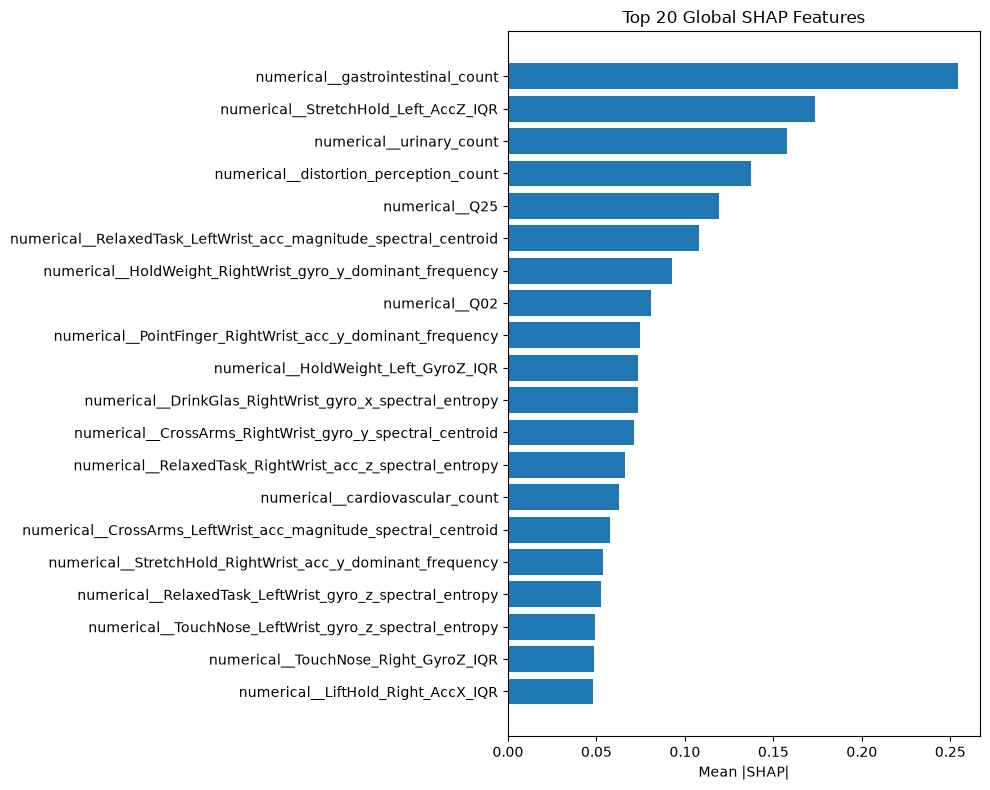

In [11]:
# Global SHAP bar plot
plt.figure(figsize=(10,8))
top20 = importance_df.head(20)
plt.barh(
    top20["Feature"][::-1],
    top20["Mean |SHAP|"][::-1]
)
plt.xlabel("Mean |SHAP|")
plt.title(
    "Top 20 Global SHAP Features"
)
plt.tight_layout()
plt.show()

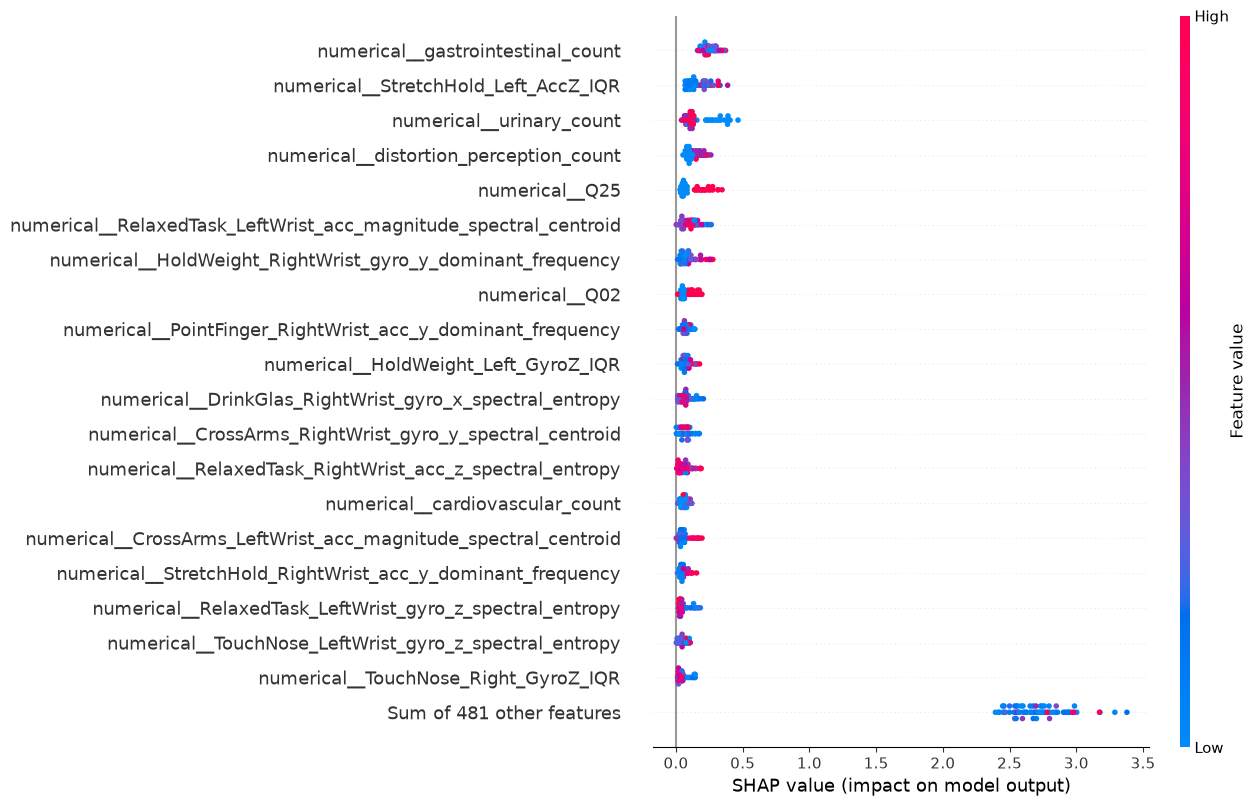

In [12]:
# Global SHAP beeswarm
mean_shap = np.mean(
    np.abs(shap_values),
    axis=2
)
explanation = shap.Explanation(
    values=mean_shap,
    data=X_processed.values,
    feature_names=selected_features
)
shap.plots.beeswarm(
    explanation,
    max_display=20
)

In [13]:
# Save SHAP importance
importance_df.to_csv(
    SHAP_TABLES / "global_shap_importance.csv",
    index=False
)
print(
    "Saved:",
    SHAP_TABLES/ "global_shap_importance.csv"
)

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\global_shap_importance.csv


### Observation
Global SHAP analysis indicated that the final Full Multimodal Random Forest model relied on both questionnaire-derived and wearable-derived features when making multiclass predictions.

The highest-ranked feature was `total_symptom_count`, an engineered summary variable representing the overall burden of non-motor symptoms. Additional influential questionnaire-derived variables included `distortion_perception_count`, `gastrointestinal_count`, `Q25`, and `Q02`, while important wearable features were extracted from accelerometer and gyroscope signals during multiple neurological tasks.

Overall, the SHAP analysis suggests that the model integrates complementary information from both questionnaire responses and movement recordings rather than relying on a single modality. Because some questionnaire-derived variables are aggregated from individual symptom responses, their importance should be interpreted as reflecting the contribution of the underlying symptom information rather than as independent clinical predictors.

## Class-Specific SHAP Analysis

Although the global SHAP analysis summarizes feature importance across all diagnostic classes, multiclass classification requires understanding which variables contribute most strongly to each individual class.

This section calculates class-specific SHAP importance for:

- Healthy Controls (Class 0)
- Parkinson's Disease (Class 1)
- Other Movement Disorders (Class 2)

For each diagnostic group, the mean absolute SHAP value is calculated across all participants to identify the features that most strongly influence predictions for that class.

In [14]:
CLASS_NAMES = {
    0: "Healthy",
    1: "Parkinson's Disease",
    2: "Other Movement Disorders"
}

class_importance = {}

for class_idx in range(len(CLASS_NAMES)):
    importance = np.mean(
        np.abs(shap_values[:, :, class_idx]),
        axis=0
    )
    df = (
        pd.DataFrame({
            "Feature": selected_features,
            "Mean |SHAP|": importance
        })
        .sort_values(
            "Mean |SHAP|",
            ascending=False
        )
        .reset_index(drop=True)
    )
    class_importance[class_idx] = df
    print("\n")
    print("="*60)
    print(CLASS_NAMES[class_idx])
    display(df.head(15))



Healthy


,Feature,Mean |SHAP|
0,numerical__gastrointestinal_count,0.762196
1,numerical__StretchHold_Left_AccZ_IQR,0.520540
2,numerical__RelaxedTask_LeftWrist_acc_magnitude...,0.323688
3,numerical__Q25,0.251086
4,numerical__HoldWeight_RightWrist_gyro_y_domina...,0.250137
5,numerical__cardiovascular_count,0.186117
6,numerical__LiftHold_Right_AccX_IQR,0.136783
7,numerical__HoldWeight_RightWrist_gyro_y_spectr...,0.131141
8,numerical__RelaxedTask_RightWrist_acc_z_spectr...,0.129883
9,numerical__Relaxed_RightWrist_gyro_z_spectral_...,0.101852




Parkinson's Disease


,Feature,Mean |SHAP|
0,numerical__urinary_count,0.449369
1,numerical__distortion_perception_count,0.411558
2,numerical__Q02,0.212693
3,numerical__RelaxedTask_LeftWrist_gyro_z_spectr...,0.140916
4,numerical__TouchNose_Left_GyroY_Median,0.138491
5,numerical__TouchNose_Right_GyroZ_IQR,0.136933
6,numerical__RelaxedTask_RightWrist_acc_y_spectr...,0.123507
7,numerical__Q25,0.106559
8,numerical__StretchHold_RightWrist_acc_y_domina...,0.103437
9,numerical__TouchNose_LeftWrist_gyro_z_spectral...,0.103018




Other Movement Disorders


,Feature,Mean |SHAP|
0,numerical__DrinkGlas_RightWrist_gyro_x_spectra...,0.214671
1,numerical__CrossArms_RightWrist_gyro_y_spectra...,0.213146
2,numerical__HoldWeight_Left_GyroZ_IQR,0.201582
3,numerical__PointFinger_RightWrist_acc_y_domina...,0.184699
4,numerical__CrossArms_LeftWrist_acc_magnitude_s...,0.169204
5,numerical__DrinkGlas_Left_AccMag_Mean,0.119997
6,numerical__CrossArms_Left_AccMag_Min,0.108140
7,numerical__Entrainment_LeftWrist_acc_z_spectra...,0.099269
8,numerical__TouchIndex_Right_AccX_Median,0.088331
9,numerical__TouchNose_Right_GyroX_IQR,0.072384


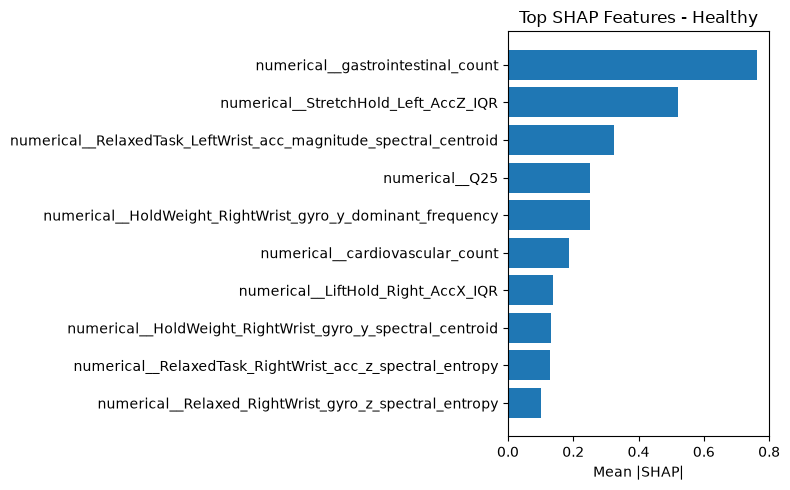

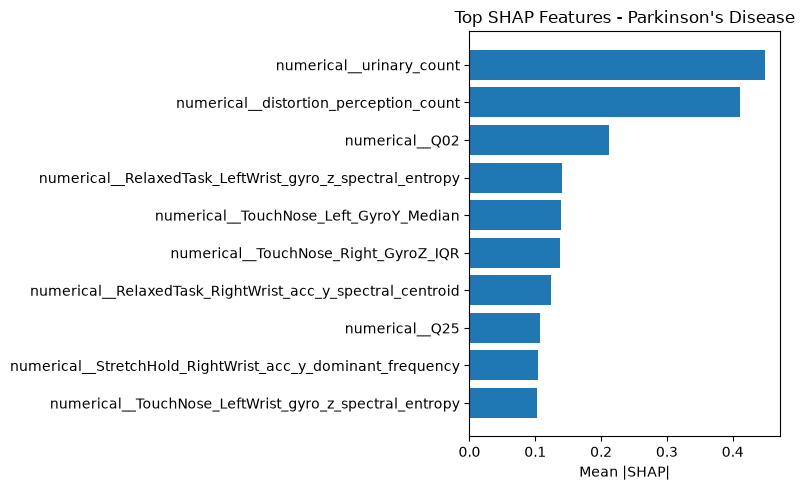

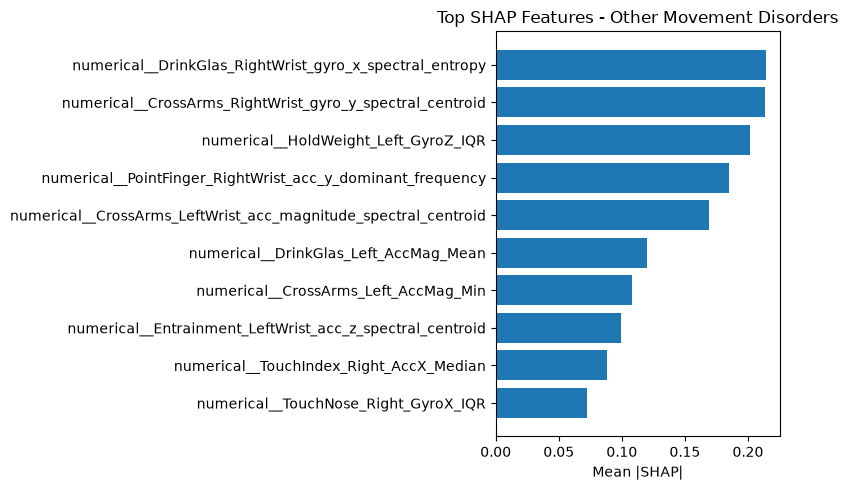

In [15]:
for class_idx in range(len(CLASS_NAMES)):
    top = class_importance[class_idx].head(10)
    plt.figure(figsize=(8,5))
    plt.barh(
        top["Feature"][::-1],
        top["Mean |SHAP|"][::-1]
    )
    plt.title(
        f"Top SHAP Features - {CLASS_NAMES[class_idx]}"
    )
    plt.xlabel("Mean |SHAP|")
    plt.tight_layout()
    plt.show()

In [16]:
# Save class-specific SHAP tables
for class_idx in range(len(CLASS_NAMES)):
    safe_name = (
        CLASS_NAMES[class_idx]
        .replace(" ", "_")
        .replace("'", "")
    )
    output_path = (
        SHAP_TABLES
        / f"shap_importance_{safe_name}.csv"
    )
    class_importance[class_idx].to_csv(
        output_path,
        index=False
    )
    print(f"Saved: {output_path}")

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_importance_Healthy.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_importance_Parkinsons_Disease.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_importance_Other_Movement_Disorders.csv


### Observation

Class-specific SHAP analysis revealed that different groups of features contributed to the prediction of each diagnostic class.

For the Healthy class, the model relied primarily on the total symptom count together with gastrointestinal symptoms, questionnaire responses, and several movement features extracted from wrist-based accelerometer and gyroscope signals.

For Parkinson's Disease, non-motor symptom variables remained highly influential, particularly the total symptom count, distortion/perception-related symptoms, gastrointestinal symptoms, and questionnaire items. Movement features from the Hold Weight, Cross Arms, Touch Nose, and Touch Index tasks also contributed substantially to Parkinson's disease predictions.

In contrast, predictions for the Other Movement Disorders class relied more heavily on movement-derived features than on questionnaire variables. Spectral characteristics extracted from gyroscope and accelerometer signals during the Cross Arms, Hold Weight, and Relaxed tasks appeared among the most influential predictors.

Overall, these results suggest that the model combines information from both wearable sensor recordings and questionnaire-derived variables. While questionnaire-derived symptom counts contribute strongly to distinguishing Healthy participants and Parkinson's disease cases, movement-based signal features become more prominent when differentiating Other Movement Disorders.

## SHAP Importance by Modality

The previous analysis examined feature importance individually. To improve interpretability, the selected features are grouped into higher-level data modalities.

Each selected feature is assigned to one of the following categories:

- Wearable Sensor Features
- Questionnaire Features
- Demographic Features

The mean absolute SHAP values are then aggregated within each modality to estimate the overall contribution of each data source to the final predictions.

In [17]:
def identify_modality(feature):
    feature = feature.lower()
    if "__q" in feature:
        return "Questionnaire"
    if "count" in feature:
        return "Questionnaire"
    if "gender" in feature:
        return "Demographics"
    if "handedness" in feature:
        return "Demographics"
    if "family_history" in feature:
        return "Demographics"
    return "Wearable Sensors"

In [18]:
importance_df["Modality"] = (
    importance_df["Feature"]
    .apply(identify_modality)
)
modality_importance = (
    importance_df
    .groupby("Modality")["Mean |SHAP|"]
    .sum()
    .reset_index()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)
display(modality_importance)

,Modality,Mean |SHAP|
2,Wearable Sensors,3.663672
1,Questionnaire,0.860253
0,Demographics,0.000000


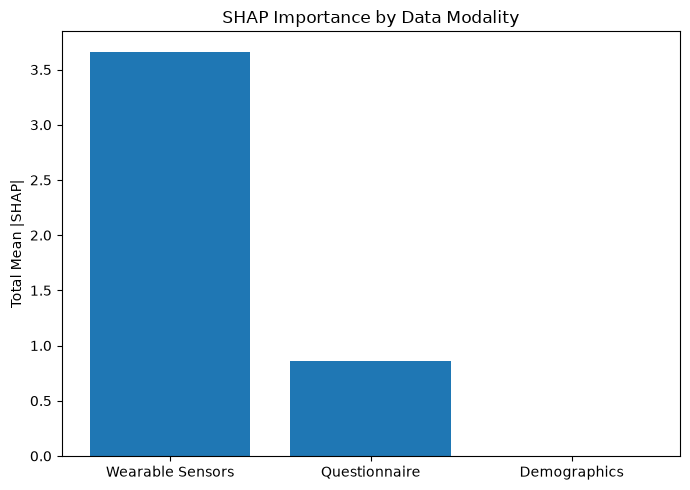

In [19]:
plt.figure(figsize=(7,5))
plt.bar(
    modality_importance["Modality"],
    modality_importance["Mean |SHAP|"]
)
plt.ylabel("Total Mean |SHAP|")
plt.title("SHAP Importance by Data Modality")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "shap_modality_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [20]:
modality_importance.to_csv(
    SHAP_TABLES / "shap_modality_importance.csv",
    index=False
)
print("Saved:", SHAP_TABLES / "shap_modality_importance.csv")

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_modality_importance.csv


### Observation

The aggregated SHAP analysis indicates how much each data modality contributed to the final model predictions.

Wearable sensor features represented the largest proportion of the model's explanatory power, reflecting the importance of movement characteristics captured during the neurological assessment tasks.

Questionnaire-derived variables also contributed substantially, particularly through symptom-related items and aggregated non-motor symptom counts.

Demographic variables showed comparatively lower overall importance, suggesting that movement characteristics and symptom information provided greater predictive value than demographic characteristics alone.

## SHAP Importance by Neurological Task

To better understand which neurological assessments contributed most to the model predictions, the selected SHAP feature importances were grouped according to the task from which each wearable feature was extracted.

Questionnaire and demographic variables were grouped separately because they are not associated with a specific movement task.

This aggregation provides a higher-level interpretation of the model by identifying the clinical tasks that contributed most strongly to the final predictions.

In [21]:
TASKS = [
    "CrossArms",
    "DrinkGlas",
    "Entrainment",
    "HoldWeight",
    "LiftHold",
    "RelaxedTask",
    "Relaxed",
    "TouchIndex",
    "TouchNose"
]

def identify_task(feature):

    for task in TASKS:
        if task.lower() in feature.lower():
            return task

    return np.nan

In [22]:
task_df = importance_df.copy()
task_df["Task"] = task_df["Feature"].apply(identify_task)
task_df = task_df.dropna(subset=["Task"])
task_importance = (
    task_df
    .groupby("Task")["Mean |SHAP|"]
    .sum()
    .reset_index()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)

display(task_importance)

,Task,Mean |SHAP|
3,HoldWeight,0.567397
8,TouchNose,0.560153
6,RelaxedTask,0.528101
0,CrossArms,0.408568
1,DrinkGlas,0.308099
4,LiftHold,0.285034
7,TouchIndex,0.185862
5,Relaxed,0.156640
2,Entrainment,0.057489


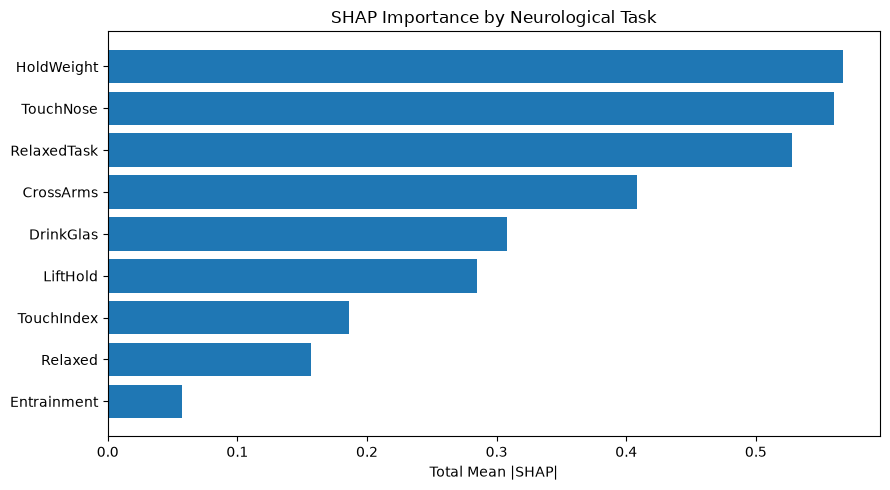

In [23]:
plt.figure(figsize=(9,5))
plt.barh(
    task_importance["Task"][::-1],
    task_importance["Mean |SHAP|"][::-1]
)
plt.xlabel("Total Mean |SHAP|")
plt.title("SHAP Importance by Neurological Task")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR /
    "shap_task_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
task_importance.to_csv(
    SHAP_TABLES /
    "shap_task_importance.csv",
    index=False
)

print(
    "Saved:",
    SHAP_TABLES /
    "shap_task_importance.csv"
)

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_task_importance.csv


### Observation

The task-level SHAP analysis showed that the model relied on multiple neurological assessment tasks rather than a single movement test.

Among the selected features, the Hold Weight and Cross Arms tasks contributed the greatest overall SHAP importance, followed by the Relaxed Task assessment. These tasks accounted for the largest proportion of the movement-related information used by the Random Forest classifier.

Other tasks, including Lift Hold, Touch Nose, Touch Index, Relaxed, and Drink Glass, also contributed to the final predictions but with comparatively lower importance.

Not all neurological tasks from the original assessment protocol were represented in the final analysis because feature selection retained only the most informative variables for the final model. Consequently, only tasks contributing selected features appear in the SHAP aggregation.

## SHAP Importance by Wrist

To further interpret the contribution of the wearable sensors, the selected SHAP feature importances were grouped according to the wrist from which the signals were collected.

Features were classified as originating from either the left wrist or the right wrist based on their feature names. Questionnaire-derived variables and demographic variables were excluded from this analysis because they are not associated with a wearable device.

The aggregated SHAP values provide an estimate of the relative contribution of each wrist to the final model predictions.

In [25]:
def identify_wrist(feature):
    feature = feature.lower()
    if "left" in feature:
        return "Left Wrist"
    if "right" in feature:
        return "Right Wrist"
    return np.nan

In [26]:
wrist_df = importance_df.copy()
wrist_df["Wrist"] = wrist_df["Feature"].apply(
    identify_wrist
)
wrist_df = wrist_df.dropna(
    subset=["Wrist"]
)
wrist_importance = (
    wrist_df
    .groupby("Wrist")["Mean |SHAP|"]
    .sum()
    .reset_index()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)
display(wrist_importance)

,Wrist,Mean |SHAP|
1,Right Wrist,1.921100
0,Left Wrist,1.715998


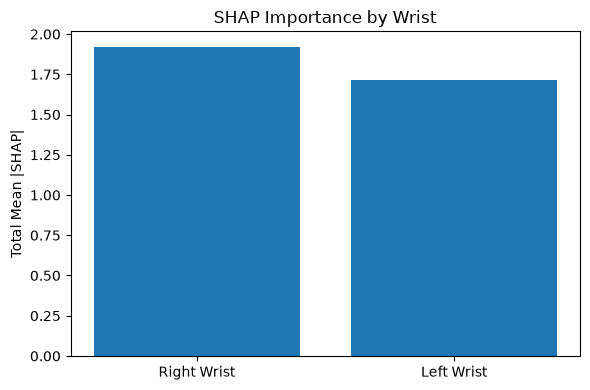

In [27]:
plt.figure(figsize=(6,4))
plt.bar(
    wrist_importance["Wrist"],
    wrist_importance["Mean |SHAP|"]
)
plt.ylabel("Total Mean |SHAP|")
plt.title(
    "SHAP Importance by Wrist"
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR /
    "shap_wrist_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [28]:
wrist_importance.to_csv(
    SHAP_TABLES /
    "shap_wrist_importance.csv",
    index=False
)
print("Saved:", SHAP_TABLES / "shap_wrist_importance.csv")

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_wrist_importance.csv


### Observation
The wrist-level SHAP aggregation indicates that both wearable devices contributed almost equally to the final predictions.
The right wrist showed a slightly higher cumulative SHAP importance than the left wrist; however, the difference was minimal. This suggests that clinically relevant movement information was captured from both sides of the body rather than relying predominantly on a single wrist.
Overall, the results support the use of bilateral wearable recordings, as both wrists provided complementary information for multiclass classification.

## SHAP Importance by Sensor Type

To investigate the relative contribution of each wearable sensor, SHAP feature importances were grouped according to the sensor from which each feature was derived.

Features extracted from accelerometer signals and gyroscope signals were aggregated separately. Questionnaire-derived variables and demographic variables were excluded because they are not associated with wearable sensors.

This analysis provides a high-level comparison of the contribution of each sensor type to the final multiclass predictions.

In [29]:
def identify_sensor(feature):
    feature = feature.lower()
    if "gyro" in feature:
        return "Gyroscope"
    if "acc" in feature:
        return "Accelerometer"
    return np.nan

In [30]:
sensor_df = importance_df.copy()
sensor_df["Sensor"] = sensor_df["Feature"].apply(
    identify_sensor
)
sensor_df = sensor_df.dropna(
    subset=["Sensor"]
)
sensor_importance = (
    sensor_df
    .groupby("Sensor")["Mean |SHAP|"]
    .sum()
    .reset_index()
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)
display(sensor_importance)

,Sensor,Mean |SHAP|
0,Accelerometer,1.833649
1,Gyroscope,1.822734


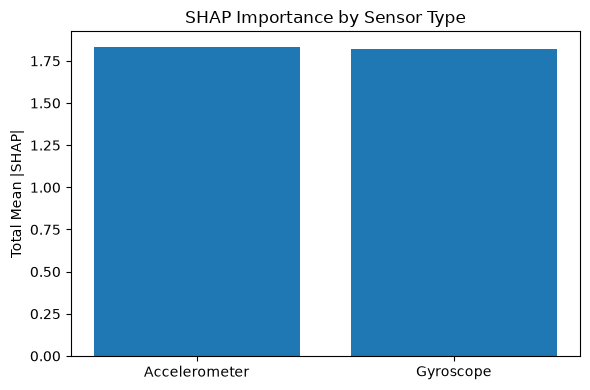

In [31]:
plt.figure(figsize=(6,4))
plt.bar(
    sensor_importance["Sensor"],
    sensor_importance["Mean |SHAP|"]
)
plt.ylabel("Total Mean |SHAP|")
plt.title("SHAP Importance by Sensor Type")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR /
    "shap_sensor_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [32]:
sensor_importance.to_csv(
    SHAP_TABLES /
    "shap_sensor_importance.csv",
    index=False
)
print(
    "Saved:",
    SHAP_TABLES /
    "shap_sensor_importance.csv"
)

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_sensor_importance.csv


### Observation

The sensor-level SHAP aggregation showed that both wearable sensors contributed substantially to the final multiclass predictions.

Gyroscope-derived features exhibited a slightly higher cumulative SHAP importance than accelerometer-derived features, suggesting that angular velocity measurements provided marginally more predictive information for the final Random Forest model. However, the relatively small difference indicates that both sensor types supplied complementary movement information.

Overall, these findings support the use of both accelerometer and gyroscope signals in the multimodal screening framework, as each sensor contributed meaningful information to the final predictions.

## SHAP Importance by Questionnaire Responses

In addition to wearable-derived movement features, the final model incorporates questionnaire variables describing non-motor symptoms associated with Parkinson's disease.

This section isolates questionnaire-related features retained after feature selection and summarizes their SHAP importance to identify which questionnaire responses contributed most strongly to the final predictions.

In [33]:
questionnaire_df = (
    importance_df[
        importance_df["Feature"]
        .str.contains(
            r"__Q\d+",
            regex=True
        )
    ]
    .copy()
)
display(questionnaire_df)

,Feature,Mean |SHAP|,Modality
4,numerical__Q25,0.119215,Questionnaire
7,numerical__Q02,0.080700,Questionnaire
92,numerical__Q01,0.012215,Questionnaire
97,numerical__Q08,0.011869,Questionnaire
173,numerical__Q22,0.005017,Questionnaire
274,numerical__Q05,0.001563,Questionnaire
305,numerical__Q09,0.000779,Questionnaire
308,numerical__Q26,0.000731,Questionnaire
351,numerical__Q15,0.000123,Questionnaire
354,numerical__Q27,0.000000,Questionnaire


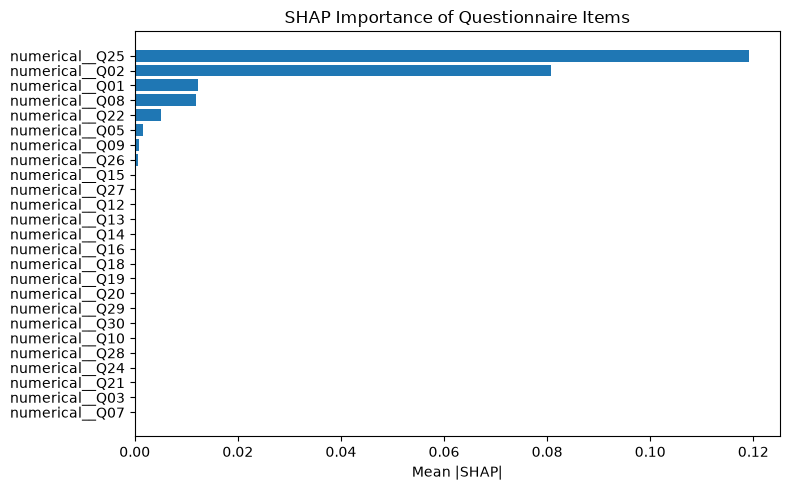

In [34]:
top_questionnaire = (
    questionnaire_df
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
)
plt.figure(figsize=(8,5))
plt.barh(
    top_questionnaire["Feature"][::-1],
    top_questionnaire["Mean |SHAP|"][::-1]
)
plt.xlabel("Mean |SHAP|")
plt.title(
    "SHAP Importance of Questionnaire Items"
)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR /
    "shap_questionnaire_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [35]:
questionnaire_labels = {
    "Q01": "Dribbling of saliva during the daytime",
    "Q02": "Loss or change in the ability to taste or smell",
    "Q03": "Difficulty swallowing food or drink",
    "Q04": "Vomiting or feelings of sickness (nausea)",
    "Q05": "Constipation or straining during bowel movements",
    "Q06": "Bowel (fecal) incontinence",
    "Q07": "Feeling of incomplete bowel emptying",
    "Q08": "Urinary urgency",
    "Q09": "Frequently getting up at night to urinate",
    "Q10": "Unexplained pain",
    "Q11": "Unexplained change in weight",
    "Q12": "Problems remembering recent events",
    "Q13": "Loss of interest in activities",
    "Q14": "Seeing or hearing things that are not there",
    "Q15": "Difficulty concentrating",
    "Q16": "Feeling sad or low",
    "Q17": "Feeling anxious or frightened",
    "Q18": "Changes in sexual interest",
    "Q19": "Difficulty having sex",
    "Q20": "Light-headedness when standing",
    "Q21": "Falling",
    "Q22": "Difficulty staying awake during activities",
    "Q23": "Difficulty falling or staying asleep",
    "Q24": "Intense or vivid dreams",
    "Q25": "Talking or moving during sleep as if acting out a dream",
    "Q26": "Unpleasant leg sensations at rest",
    "Q27": "Swelling of the legs",
    "Q28": "Excessive sweating",
    "Q29": "Double vision",
    "Q30": "Believing things that others say are not true"
}

questionnaire_table = top_questionnaire.copy()

questionnaire_table["Item"] = (
    questionnaire_table["Feature"]
    .str.extract(r"(Q\d+)")
)

questionnaire_table["Questionnaire Response"] = (
    questionnaire_table["Item"]
    .map(questionnaire_labels)
)

questionnaire_table = questionnaire_table[
    [
        "Item",
        "Questionnaire Response",
        "Mean |SHAP|"
    ]
]

questionnaire_table.insert(
    0,
    "Rank",
    range(1, len(questionnaire_table)+1)
)

questionnaire_table["Mean |SHAP|"] = (
    questionnaire_table["Mean |SHAP|"]
    .round(4)
)

display(questionnaire_table)

,Rank,Item,Questionnaire Response,Mean |SHAP|
4,1,Q25,Talking or moving during sleep as if acting ou...,0.1192
7,2,Q02,Loss or change in the ability to taste or smell,0.0807
92,3,Q01,Dribbling of saliva during the daytime,0.0122
97,4,Q08,Urinary urgency,0.0119
173,5,Q22,Difficulty staying awake during activities,0.0050
274,6,Q05,Constipation or straining during bowel movements,0.0016
305,7,Q09,Frequently getting up at night to urinate,0.0008
308,8,Q26,Unpleasant leg sensations at rest,0.0007
351,9,Q15,Difficulty concentrating,0.0001
354,10,Q27,Swelling of the legs,0.0000


In [36]:
top_questionnaire.to_csv(
    SHAP_TABLES /
    "shap_questionnaire_importance.csv",
    index=False
)
questionnaire_table.to_csv(
    SHAP_TABLES / "questionnaire_shap_summary.csv",
    index=False
)
print(
    "Saved:",
    SHAP_TABLES /
    "shap_questionnaire_importance.csv"
)
print(
    "Saved:",
    SHAP_TABLES /
    "questionnaire_shap_summary.csv"
)

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\shap_questionnaire_importance.csv
Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\shap\tables\questionnaire_shap_summary.csv


### Observation

Only 10 of the original 30 Non-Motor Symptoms (NMS) questionnaire items were retained after feature selection, indicating that the model identified a relatively small subset of questionnaire responses as informative for multiclass classification.

Among these variables, the most influential items were related to REM sleep behavior disorder (Q25), loss of smell or taste (Q02), urinary urgency (Q08), swallowing difficulties (Q03), and daytime drooling (Q01). These symptoms are widely recognized as clinically relevant non-motor manifestations associated with Parkinson's disease.

The remaining questionnaire items contributed comparatively little to the final predictions, suggesting that wearable movement features provided most of the predictive information while selected non-motor symptoms complemented the classification process.

# 2. Local SHAP Explanations
Global SHAP analysis identifies the features that are important across the entire test dataset. However, clinical decision support also requires understanding why the model generated a prediction for an individual participant.

This section presents participant-level explanations using the final Full Multimodal Random Forest classifier. Three correctly classified participants, one from each diagnostic class, are selected to illustrate how wearable-derived movement features and questionnaire variables contribute to individualized predictions.

For each participant, the following information is presented:

- True diagnosis
- Predicted diagnosis
- Prediction probabilities
- Local SHAP explanation
- Features supporting the prediction
- Features opposing the prediction

In [37]:
# Setup
classifier = pipeline.named_steps["classifier"]
classes = classifier.classes_
CLASS_NAMES = {
    0: "Healthy",
    1: "Parkinson's Disease",
    2: "Other Movement Disorders"
}
y_true = test_df["label"]
predictions = classifier.predict(X_processed)
prediction_probabilities = classifier.predict_proba(X_processed)
results_df = pd.DataFrame({
    "Participant":test_df["patient_id"],
    "True Class":y_true,
    "Predicted Class":predictions,
    "Confidence":prediction_probabilities.max(axis=1)
})
display(results_df.head())

,Participant,True Class,Predicted Class,Confidence
0,18,2,1,0.904193
1,25,1,1,0.991225
2,28,1,1,0.630845
3,43,2,1,0.678255
4,51,1,2,0.654599


In [38]:
examples = {}
for c in classes:
    idx = results_df[
        (results_df["True Class"]==c) &
        (results_df["Predicted Class"]==c)
    ].index[0]
    examples[c]=idx
example_summary=[]
for c,idx in examples.items():
    probs=prediction_probabilities[idx]
    example_summary.append({
        "Participant":
        results_df.loc[idx,"Participant"],
        "True Class":
        CLASS_NAMES[c],
        "Predicted Class":
        CLASS_NAMES[
            results_df.loc[idx,"Predicted Class"]
        ],
        "Predicted Probability":
        round(np.max(probs),3)
    })
example_summary=pd.DataFrame(example_summary)
display(example_summary)

,Participant,True Class,Predicted Class,Predicted Probability
0,160,Healthy,Healthy,0.661
1,25,Parkinson's Disease,Parkinson's Disease,0.991
2,66,Other Movement Disorders,Other Movement Disorders,0.963


### Observation

One correctly classified participant from each diagnostic class was selected to illustrate participant-level explanations. These examples demonstrate how the model combines questionnaire-derived information and wearable sensor features when generating individualized predictions.
The selected participants are representative examples intended to illustrate the model's reasoning process rather than the most confident predictions.

In [39]:
def explain_participant(idx):
    print("="*70)
    print(
        "Participant:",
        results_df.loc[idx,"Participant"]
    )
    print(
        "True class:",
        CLASS_NAMES[
            results_df.loc[idx,"True Class"]
        ]
    )
    print(
        "Predicted:",
        CLASS_NAMES[
            results_df.loc[idx,"Predicted Class"]
        ]
    )
    probs=prediction_probabilities[idx]
    prob_df=pd.DataFrame({
        "Class":[
            CLASS_NAMES[c]
            for c in classes
        ],

        "Probability":
        np.round(probs,4)
    })
    display(prob_df)
    predicted_class=np.argmax(probs)
    local_values=shap_values[
        idx,
        :,
        predicted_class
    ]
    local_df=pd.DataFrame({
        "Feature":
        selected_features,
        "SHAP":
        local_values
    })
    local_df["Absolute"]=(
        local_df["SHAP"]
        .abs()
    )
    local_df=local_df.sort_values(
        "Absolute",
        ascending=False
    )

    display(local_df.head(10))
    shap.plots.waterfall(
        shap.Explanation(

            values=local_values,

            base_values=explainer.expected_value[
                predicted_class
            ],

            data=X_processed.iloc[idx].values,

            feature_names=selected_features

        ),

        max_display=10

    )

Participant: 160
True class: Healthy
Predicted: Healthy


,Class,Probability
0,Healthy,0.6615
1,Parkinson's Disease,0.2945
2,Other Movement Disorders,0.0440


,Feature,SHAP,Absolute
368,numerical__RelaxedTask_LeftWrist_acc_magnitude...,0.774713,0.774713
485,numerical__gastrointestinal_count,0.734587,0.734587
62,numerical__StretchHold_Left_AccZ_IQR,0.384275,0.384275
328,numerical__HoldWeight_RightWrist_gyro_y_domina...,0.191424,0.191424
408,numerical__Relaxed_RightWrist_gyro_z_spectral_...,-0.139911,0.139911
71,numerical__TouchNose_Right_GyroX_Median,-0.138060,0.138060
13,numerical__LiftHold_Right_AccX_IQR,0.130556,0.130556
479,numerical__Q25,0.126484,0.126484
415,numerical__StretchHold_RightWrist_acc_x_domina...,-0.122931,0.122931
333,numerical__LiftHold_LeftWrist_acc_x_dominant_f...,0.111147,0.111147


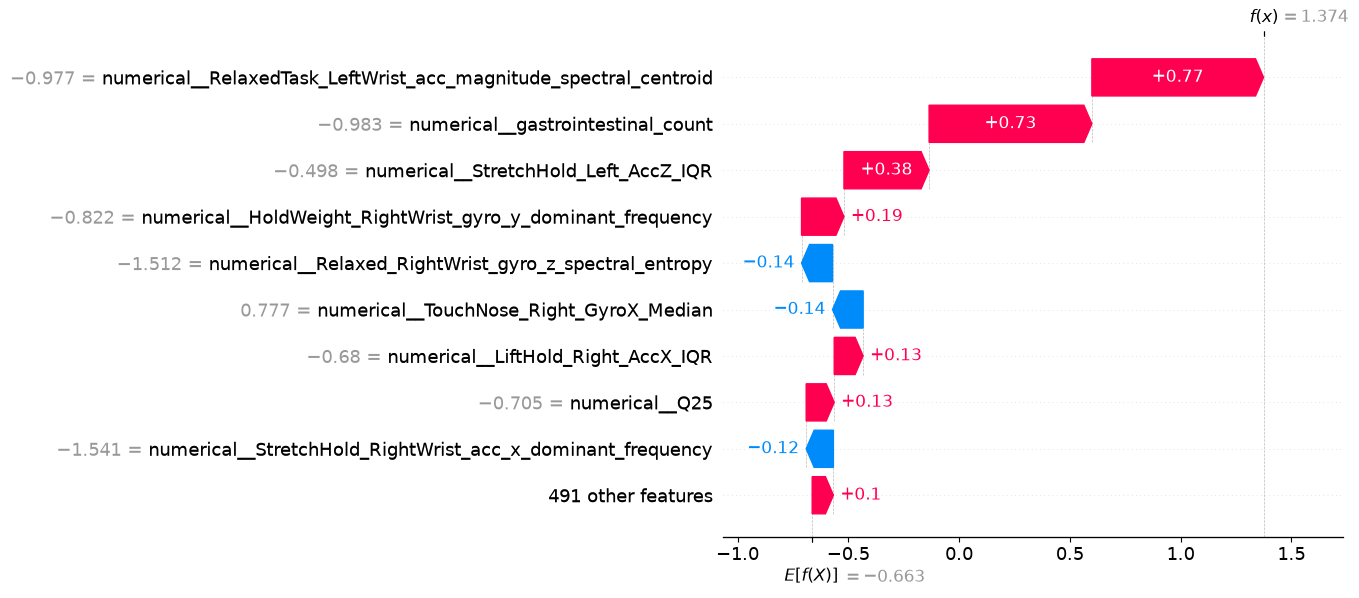

In [40]:
explain_participant(
    examples[0]
)

Participant: 25
True class: Parkinson's Disease
Predicted: Parkinson's Disease


,Class,Probability
0,Healthy,0.0031
1,Parkinson's Disease,0.9912
2,Other Movement Disorders,0.0057


,Feature,SHAP,Absolute
490,numerical__distortion_perception_count,0.626146,0.626146
486,numerical__urinary_count,0.390464,0.390464
45,numerical__TouchNose_Left_AccZ_Median,0.258700,0.258700
103,numerical__TouchNose_Left_GyroY_Median,-0.199291,0.199291
461,numerical__Q02,-0.162443,0.162443
479,numerical__Q25,0.159521,0.159521
381,numerical__RelaxedTask_RightWrist_acc_y_spectr...,0.141178,0.141178
335,numerical__LiftHold_LeftWrist_acc_x_spectral_e...,0.101694,0.101694
418,numerical__StretchHold_RightWrist_acc_y_domina...,-0.074698,0.074698
156,numerical__TouchNose_Right_GyroZ_IQR,0.059224,0.059224


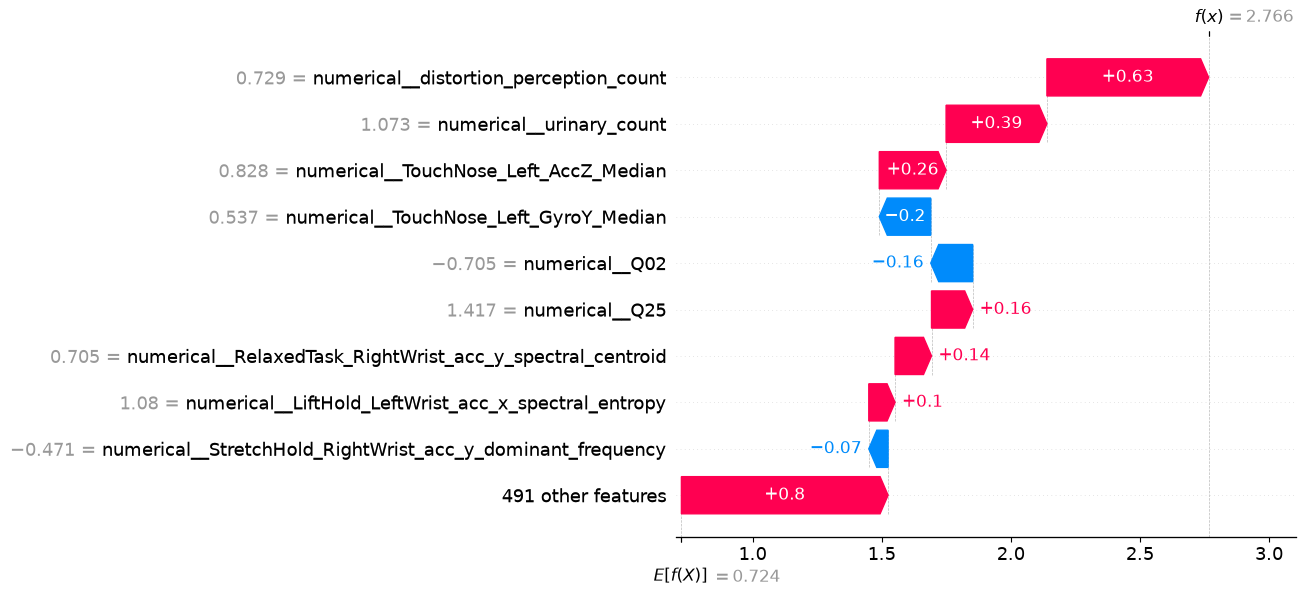

In [41]:
explain_participant(
    examples[1]
)

Participant: 66
True class: Other Movement Disorders
Predicted: Other Movement Disorders


,Class,Probability
0,Healthy,0.0103
1,Parkinson's Disease,0.0270
2,Other Movement Disorders,0.9627


,Feature,SHAP,Absolute
297,numerical__Entrainment_LeftWrist_acc_z_spectra...,-0.453941,0.453941
148,numerical__HoldWeight_Left_GyroZ_IQR,0.448602,0.448602
207,numerical__TouchNose_Right_GyroMag_Median,-0.332814,0.332814
246,numerical__CrossArms_LeftWrist_acc_magnitude_s...,0.296904,0.296904
365,numerical__PointFinger_RightWrist_acc_y_domina...,0.245537,0.245537
293,numerical__DrinkGlas_RightWrist_gyro_x_spectra...,0.218678,0.218678
271,numerical__CrossArms_RightWrist_gyro_y_spectra...,0.175403,0.175403
322,numerical__HoldWeight_RightWrist_acc_z_spectra...,0.163289,0.163289
47,numerical__DrinkGlas_Left_AccZ_Std,0.136191,0.136191
144,numerical__DrinkGlas_Left_GyroZ_Range,0.114697,0.114697


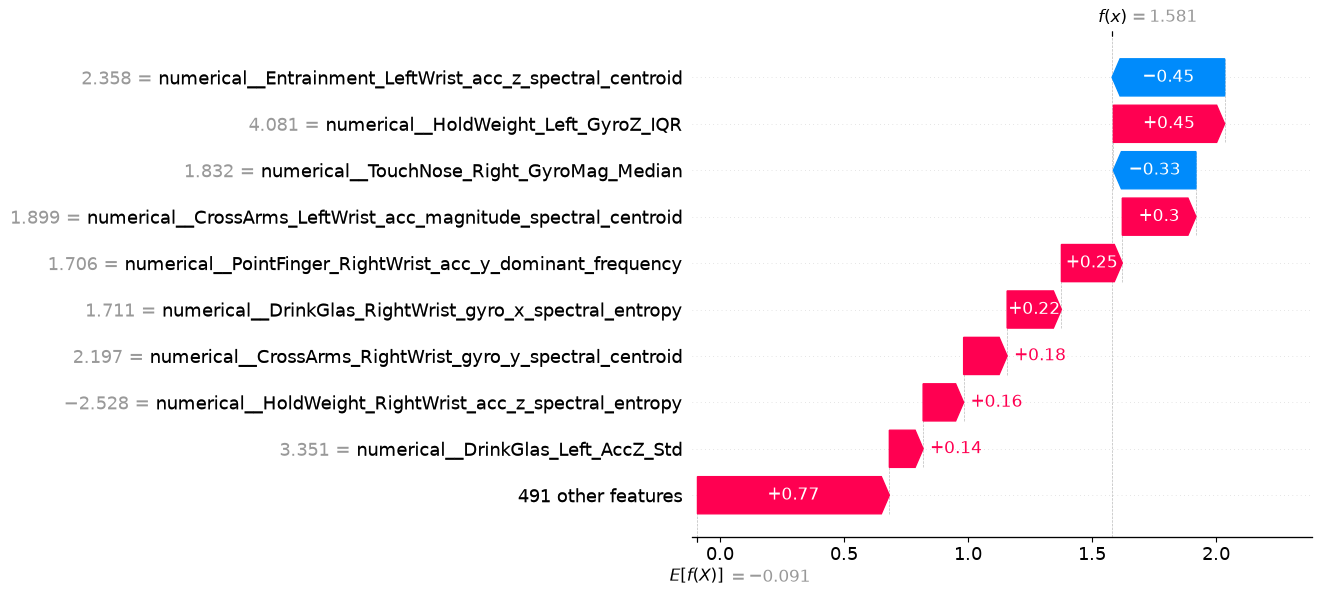

In [42]:
explain_participant(
    examples[2]
)

### Discussion

The local SHAP explanations were consistent with the global importance analysis.

For the Parkinson's Disease participant, questionnaire-derived variables (particularly Q25 and Q02) together with movement features from the HoldWeight and CrossArms tasks contributed most strongly to the final prediction.

In contrast, the participant with Other Movement Disorders was primarily characterized by wearable-derived movement features, with questionnaire variables contributing less to the final decision.

The Healthy participant exhibited a balance of positive and negative feature contributions, illustrating how the classifier integrates evidence both supporting and opposing the predicted class before reaching a final decision.

Overall, these examples demonstrate that the model bases its predictions on combinations of complementary clinical and movement-derived information rather than relying on a single dominant feature.

## Summary of SHAP Findings

The SHAP analysis provides a comprehensive interpretation of the Random Forest classifier by identifying both globally important features and participant-specific decision patterns.

Across all analyses, wearable-derived features contributed the greatest overall importance, followed by questionnaire responses, while demographic variables contributed comparatively little. Among the neurological assessment tasks, HoldWeight, CrossArms, and RelaxedTask consistently showed the highest cumulative importance, suggesting that these tasks capture the most discriminative movement characteristics for separating Healthy participants, Parkinson's Disease, and Other Movement Disorders.

Both wrists contributed almost equally to the model, indicating that clinically relevant movement information is distributed bilaterally rather than being concentrated in a single limb. Similarly, gyroscope-derived features showed only a slight advantage over accelerometer-derived features, supporting the complementary value of both sensor modalities.

Within the questionnaire, symptoms related to REM sleep behavior (Q25), olfactory dysfunction (Q02), urinary urgency (Q08), swallowing difficulty (Q03), and excessive salivation (Q01) consistently ranked among the most informative non-motor symptoms.

Finally, local SHAP explanations demonstrated that individual predictions are generated through combinations of movement characteristics and questionnaire responses rather than relying on any single feature, providing transparent and clinically interpretable explanations for each prediction.

## Limitations

Although SHAP provides valuable insight into feature importance and individual predictions, several limitations should be considered.

First, SHAP explanations reflect the behavior of the trained Random Forest model rather than establishing causal relationships between clinical variables and disease status. Features identified as highly important should therefore be interpreted as influential for the model's predictions rather than definitive clinical biomarkers.

Second, feature importance was computed after preprocessing and feature selection. Consequently, the explanations are restricted to the final subset of 50 selected variables and do not represent the full set of original wearable, questionnaire, and demographic variables.

Finally, local explanations describe the reasoning behind individual predictions and may vary across participants. Therefore, individual SHAP plots should be interpreted together with the global importance analysis to obtain a complete understanding of the model's behavior.